In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data")
weekly = pd.read_parquet(DATA / "weekly_article_sales.parquet")
print(weekly.shape)

(2210899, 14)


In [2]:
dates = pd.read_parquet(DATA / "transactions.parquet", columns=["t_dat"])["t_dat"]
print("First sale:", dates.min(), "->", dates.min().day_name())
print("Last sale: ", dates.max(), "->", dates.max().day_name())
del dates

First sale: 2018-09-20 00:00:00 -> Thursday
Last sale:  2020-09-22 00:00:00 -> Tuesday


In [3]:
first_full_week = weekly["week"].min() + pd.Timedelta(weeks=1)
last_full_week = weekly["week"].max() - pd.Timedelta(weeks=1)

weekly = weekly[(weekly["week"] >= first_full_week) &
                (weekly["week"] <= last_full_week)].copy()

print(weekly["week"].min(), "to", weekly["week"].max())
print(weekly.shape)

2018-09-24 00:00:00 to 2020-09-14 00:00:00
(2181762, 14)


In [4]:
ARTICLE = 108775015

one = pd.read_parquet(
    DATA / "transactions.parquet",
    columns=["t_dat", "article_id", "price", "sales_channel_id"],
    filters=[("article_id", "==", ARTICLE)],
)
one["week"] = one["t_dat"] - pd.to_timedelta(one["t_dat"].dt.dayofweek, unit="D")
print(one.shape)

# price level in each channel (1 = store, 2 = online)
one.groupby("sales_channel_id")["price"].describe()

(10841, 5)


,count,mean,std,min,25%,50%,75%,max
sales_channel_id,,,,,,,,
1,2485.0,0.007984,0.000858,0.001339,0.007610,0.008458,0.008458,0.008458
2,8356.0,0.008189,0.000568,0.004864,0.008458,0.008458,0.008458,0.009153


In [5]:
one["price"].round(5).value_counts().head(10)

price
0.00846    8176
0.00676     946
0.00761     354
0.00719     197
0.00678     103
0.00720      73
0.00763      60
0.00753      38
0.00803      36
0.00717      36
Name: count, dtype: int64

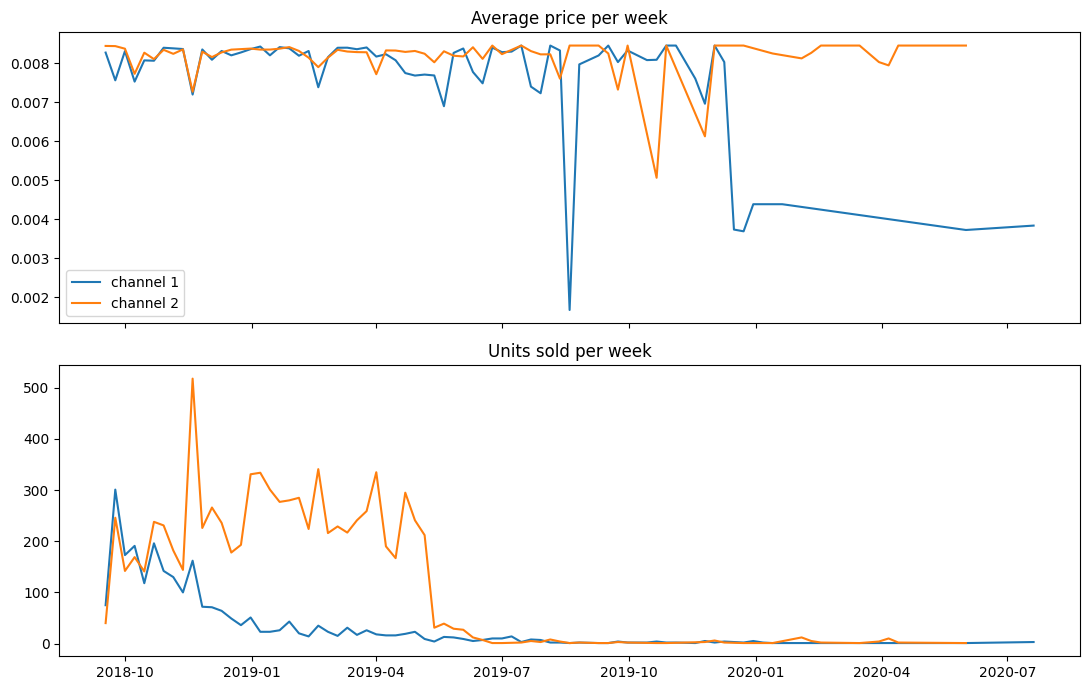

In [6]:
by_channel = (
    one.groupby(["week", "sales_channel_id"])
       .agg(units=("price", "size"), avg_price=("price", "mean"))
       .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ch, g in by_channel.groupby("sales_channel_id"):
    axes[0].plot(g["week"], g["avg_price"], label=f"channel {ch}")
    axes[1].plot(g["week"], g["units"], label=f"channel {ch}")

axes[0].set_title("Average price per week")
axes[0].legend()
axes[1].set_title("Units sold per week")
plt.tight_layout()
plt.show()

In [7]:
cat = (
    weekly.groupby("product_type_name", observed=True)
          .agg(units=("units", "sum"),
               revenue=("revenue", "sum"),
               products=("article_id", "nunique"))
          .sort_values("revenue", ascending=False)
)
cat["avg_price"] = cat["revenue"] / cat["units"]      # price per unit sold
cat["revenue_share"] = (cat["revenue"] / cat["revenue"].sum()).round(3)
cat.head(15)

,units,revenue,products,avg_price,revenue_share
product_type_name,,,,,
Trousers,4174759,149323.088570,11015,0.035768,0.170
Dress,3223647,117609.440711,10234,0.036483,0.134
Sweater,2745765,79638.917237,9134,0.029004,0.091
Blouse,1493479,42058.569360,3927,0.028161,0.048
Jacket,593915,39923.470355,3850,0.067221,0.046
Skirt,928700,33017.057773,2671,0.035552,0.038
Top,1572100,31865.397695,4096,0.020269,0.036
Bra,1327348,31784.098963,2187,0.023946,0.036
T-shirt,2189694,30072.715902,7861,0.013734,0.034


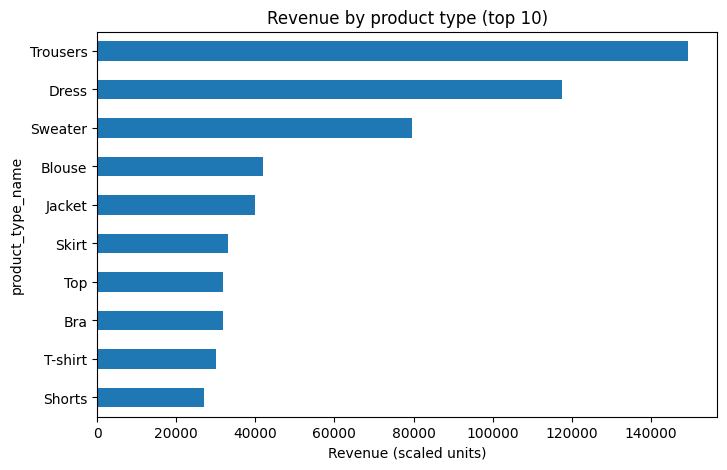

In [8]:
cat["revenue"].head(10).sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Revenue by product type (top 10)")
plt.xlabel("Revenue (scaled units)")
plt.show()

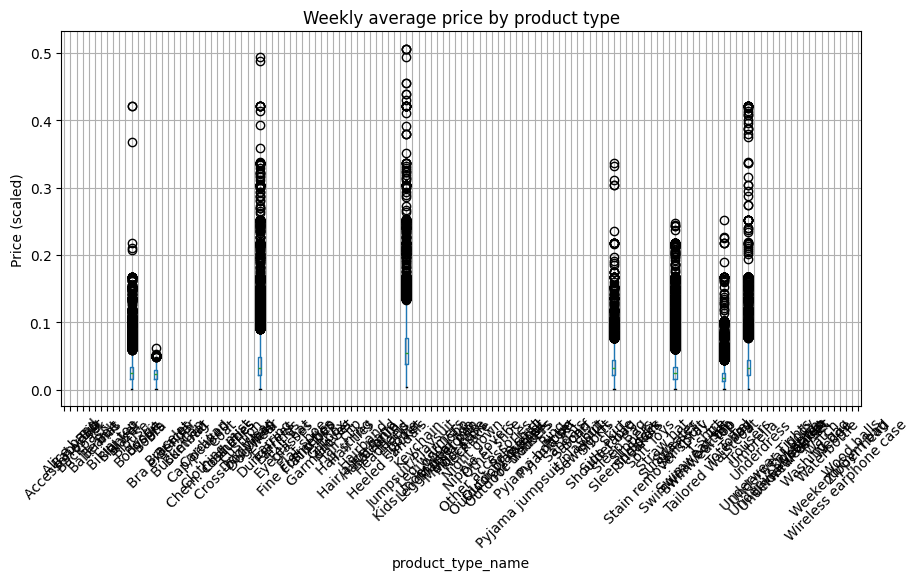

In [9]:
top_types = cat.head(8).index
subset = weekly[weekly["product_type_name"].isin(top_types)].sample(200_000, random_state=1)

subset.boxplot(column="avg_price", by="product_type_name", rot=45, figsize=(10, 5))
plt.suptitle("")
plt.title("Weekly average price by product type")
plt.ylabel("Price (scaled)")
plt.show()

In [10]:
art = weekly.groupby("article_id").agg(
    weeks=("week", "nunique"),
    total_units=("units", "sum"),
)

eligible = art[(art["weeks"] >= 20) & (art["total_units"] >= 200)]

print("All products:     ", len(art))
print("Eligible products:", len(eligible))
print("Share of products:", round(len(eligible) / len(art), 3))
print("Share of units sold they cover:",
      round(art.loc[eligible.index, "total_units"].sum() / art["total_units"].sum(), 3))

All products:      104195
Eligible products: 27832
Share of products: 0.267
Share of units sold they cover: 0.828
